In [1]:
import numpy as np
import pickle
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import json

In [2]:
DISEASE = input("Disease: ")
OUTPUT_DIRECTORY = f"../output/{DISEASE}/"
NONE_OUTPUT_DIRECTORY = f"../output/NONE/"
DGIDB_DIRECTORY = f"../../Gen_Hypergraph/output/DGIDB_{DISEASE}/"
MSIGDB_DIRECTORY = "../../Gen_Hypergraph/output/MSigDB_Full/"

In [ ]:
# load selected communities
with open(f"{OUTPUT_DIRECTORY}/result_communities_selected.pkl", "rb") as f:
    communities_selected = pickle.load(f)

In [4]:
with open(DGIDB_DIRECTORY + "gene_to_index.json", "r") as file:
    dgidb = json.load(file)
with open(MSIGDB_DIRECTORY + "gene_to_index.json", "r") as file:
    msigdb = json.load(file)
with open(OUTPUT_DIRECTORY + "gene_to_index_distinct.json", "r") as file:
    gene_to_index_distinct = json.load(file)

In [5]:
index_to_gene_distinct = {index: gene for gene, index in gene_to_index_distinct.items()}

In [6]:
# concatenate all genes from selected communities
all_genes = []
for community in communities_selected:
    all_genes.extend(community)
print(all_genes)

[4006, 455, 4950, 6691, 4163, 7707, 11733, 6485, 1824, 6398, 1878, 10381, 77, 3815, 6549, 6868, 1517, 7755, 2812, 5016, 1166, 5577, 6881, 6270, 6002, 5482, 8718, 10109, 11868, 8785, 3375, 2831, 4633, 2364, 8254, 958, 6290, 16395, 15000, 6845, 13336, 7968, 2743, 6848, 6452, 669, 15029, 720, 2358, 4320, 2830, 8470, 2690, 11681, 1317, 4358, 2415, 6995, 2361, 2844, 13360, 9328, 13070, 1098, 3600, 7593, 15119, 5865, 3004, 7199, 153, 603, 1007, 5473, 7666, 716, 10636, 2162, 8627, 9055, 17647, 828, 14145, 17017, 15181, 3223, 4953, 15528, 7851, 3598, 8638, 8061, 13540, 11645, 11103, 6513, 3038, 292, 11363, 6228, 7402, 8703, 9593, 2479, 7048, 5057, 16641, 703, 1417, 7211, 10606, 508, 1579, 4540, 4618, 4170, 2816, 9780, 4333, 14922, 8721, 2762, 1434, 1436, 2854, 1508, 10525, 7275, 10445, 727, 13992, 12595, 3597, 12431, 6130, 13077, 984, 7647, 1321, 11567, 14268, 1518, 10327, 2836, 408, 18734, 789, 1336, 3967, 4332, 2837, 1998, 17238, 7345, 13212, 10170, 4431, 9210, 2418, 6186, 5464, 5018, 12954,

In [7]:
len(all_genes)

8169

In [8]:
all_genes_M = [msigdb.get(index_to_gene_distinct[gene_idx]) for gene_idx in all_genes]

In [9]:
# DGIDB-only genes are not in selected communities
len(all_genes_M)

8169

In [10]:
# with open(DGIDB_DIRECTORY + "gene_to_index.json", "r") as file:
#     dgidb = json.load(file)

In [11]:
# all_genes = list(range(len(dgidb)))

In [12]:
# load eigenvalues and eigenvectors
eigenvalues = np.load(OUTPUT_DIRECTORY + "eigenvalues.npy")
eigenvectors = np.load(OUTPUT_DIRECTORY + "eigenvectors.npy")

In [13]:
# # load eigenvalues and eigenvectors single-layer
# eigenvalues_M = np.load(OUTPUT_DIRECTORY + "eigenvalues_M.npy")
# eigenvectors_P_M = np.load(OUTPUT_DIRECTORY + "eigenvectors_P_M.npy")

In [14]:
# load eigenvalues and eigenvectors single-layer
eigenvalues_M = np.load(NONE_OUTPUT_DIRECTORY + "eigenvalues.npy")
eigenvectors_M = np.load(NONE_OUTPUT_DIRECTORY + "eigenvectors.npy")

# Top eigenvalues magnitude

In [15]:
top_eigenvalues = eigenvalues[:20]
top_eigenvalues_M = eigenvalues_M[:20]

In [16]:
font_size = 25
tick_font_size = 16
plt.rcParams.update({
    "font.size": font_size,          # base font size
    "axes.titlesize": font_size,
    "axes.labelsize": font_size,
    "xtick.labelsize": tick_font_size,
    "ytick.labelsize": tick_font_size,
    "legend.fontsize": font_size,
    "figure.titlesize": font_size,
    "legend.loc": 'best'
})


c:\Users\celem\AppData\Local\Programs\Python\Python310\lib\site-packages\matplotlib\cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
c:\Users\celem\AppData\Local\Programs\Python\Python310\lib\site-packages\matplotlib\collections.py:200: ComplexWarning: Casting complex values to real discards the imaginary part
  offsets = np.asanyarray(offsets, float)


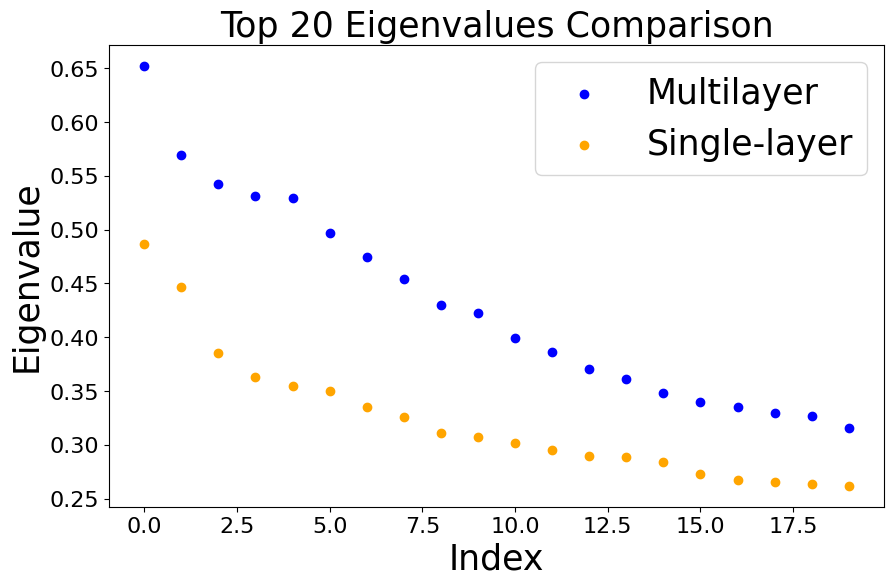

In [27]:
# plot eigenvalues comparison, dot plot, blue for multilayer, orange for single-layer
plt.figure(figsize=(10,6))
plt.scatter(range(len(top_eigenvalues)), top_eigenvalues, label="Multilayer", color='blue')
plt.scatter(range(len(top_eigenvalues_M)), top_eigenvalues_M, label="Single-layer", color='orange')
plt.xlabel("Index")
plt.ylabel("Eigenvalue")
plt.title("Top 20 Eigenvalues Comparison")
# put legend outside the plot
plt.legend()
plt.savefig(f"../../Graphs/{DISEASE}/top_20_eigenvalues_comparison.png")

# 2D eigenvalues embedding plots

In [18]:
lambda1,lambda2 = eigenvalues[1],eigenvalues[2]
phi1,phi2 = eigenvectors[:,1],eigenvectors[:,2]

In [19]:
lambda1_M,lambda2_M = eigenvalues_M[1],eigenvalues_M[2]
phi1_M,phi2_M = eigenvectors_M[:,1],eigenvectors_M[:,2]

In [20]:
def embedding(gene_idx,t):
    return np.array([(lambda1**t)*phi1[gene_idx], 
                     (lambda2**t)*phi2[gene_idx]])

In [21]:
def embedding_M(gene_idx,t):
    return np.array([(lambda1_M**t)*phi1_M[gene_idx], 
                     (lambda2_M**t)*phi2_M[gene_idx]])

In [22]:
embeddings = np.array([embedding(gene_idx, t=6) for gene_idx in all_genes])
print(embeddings)

[[ 6.99160521e-05+0.j -2.54236809e-05+0.j]
 [ 1.34046184e-04+0.j  2.30910840e-05+0.j]
 [ 2.71901268e-05+0.j -8.09784748e-05+0.j]
 ...
 [ 5.95582912e-05+0.j -3.18468499e-05+0.j]
 [ 5.79762408e-05+0.j -7.08200618e-05+0.j]
 [ 5.56428607e-05+0.j -3.39256495e-05+0.j]]


In [23]:
embeddings_M = np.array([embedding_M(gene_idx, t=6) for gene_idx in all_genes_M])
print(embeddings_M)

[[-3.80038453e-05+0.j  5.66328866e-06+0.j]
 [-4.32008176e-05+0.j  2.35018032e-06+0.j]
 [-4.62896449e-05+0.j  1.48249511e-06+0.j]
 ...
 [-4.24972490e-05+0.j -1.58698658e-05+0.j]
 [-2.75120738e-05+0.j -1.81079897e-05+0.j]
 [-4.71796154e-05+0.j -1.98476976e-05+0.j]]


In [24]:
x,y=embeddings[:,0],embeddings[:,1]

In [25]:
x_M,y_M=embeddings_M[:,0],embeddings_M[:,1]

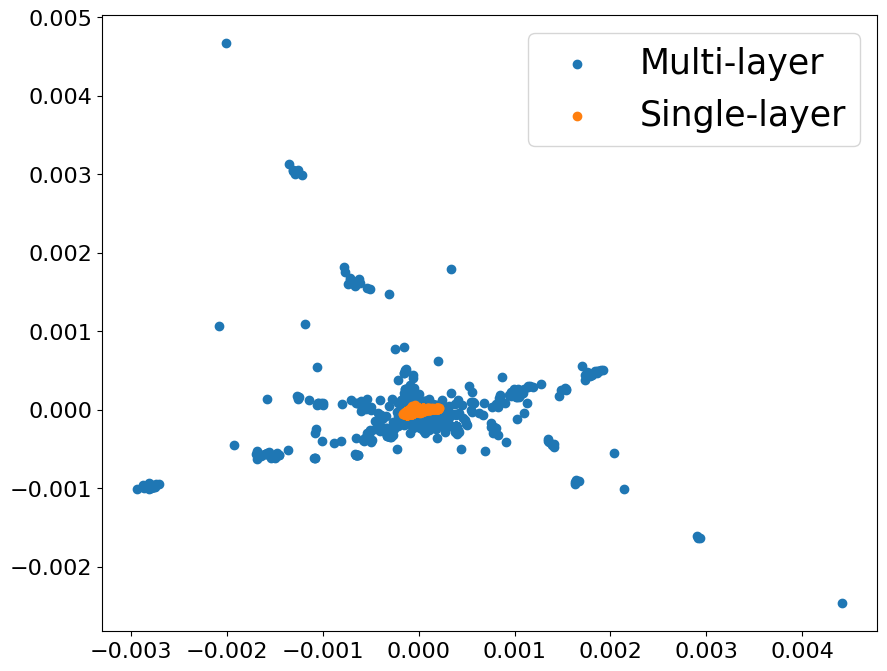

In [30]:
plt.figure(figsize=(10,8))

plt.scatter(x, y, label="Multi-layer")
plt.scatter(x_M, y_M, label="Single-layer")

plt.legend()

plt.savefig(f"../../Graphs/{DISEASE}/eigen_embedding_comparison.png")

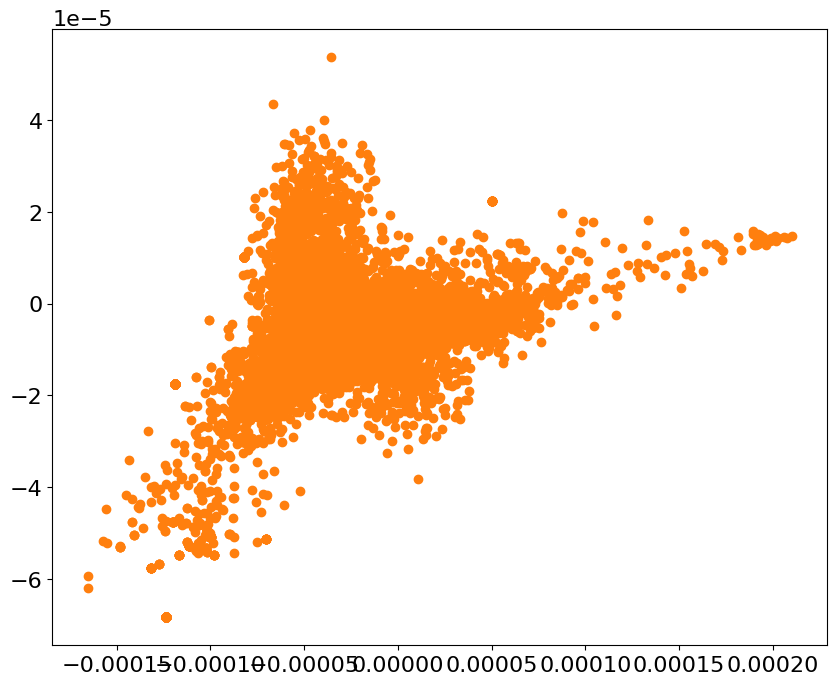

In [35]:
plt.figure(figsize=(10,8))
plt.scatter(x_M, y_M, color = '#ff7f0e', label="Single-layer")
plt.savefig(f"../../Graphs/{DISEASE}/eigen_embedding_single_layer.png")

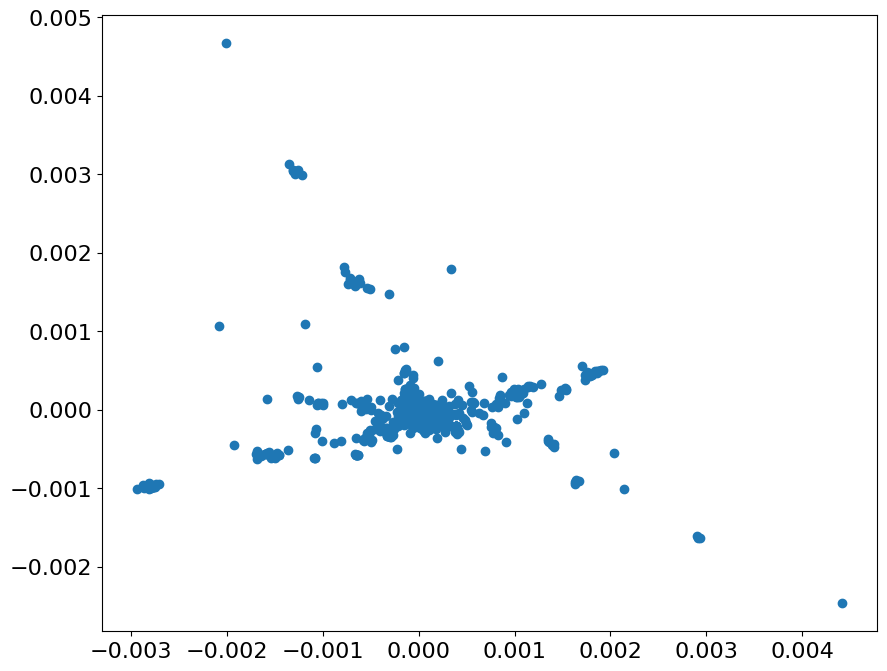

In [34]:
plt.figure(figsize=(10,8))
plt.scatter(x, y, color = '#1f77b4', label="Single-layer")
plt.savefig(f"../../Graphs/{DISEASE}/eigen_embedding_multi_layer.png")